### Подключаем библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.ma.core import resize

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve, hamming_loss)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
from optuna.samplers import TPESampler
import time
from sklearn.metrics import f1_score

C:\Users\myska\anaconda3\envs\PythonProject1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Читаем train

In [35]:
df = pd.read_csv('train.csv')
data_train = pd.read_csv('train.csv')
data_real = pd.read_csv('test.csv')
df.head(5)

,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0,584,590,909972,909977,16,8,5,2274,113,...,-0.5000,-0.0104,0.1417,0,0,0,1,0,0,0
1,1,808,816,728350,728372,433,20,54,44478,70,...,0.7419,-0.2997,0.9491,0,0,0,0,0,0,1
2,2,39,192,2212076,2212144,11388,705,420,1311391,29,...,-0.0105,-0.0944,1.0000,0,0,1,0,0,0,0
3,3,781,789,3353146,3353173,210,16,29,3202,114,...,0.6667,-0.0402,0.4025,0,0,1,0,0,0,0
4,4,1540,1560,618457,618502,521,72,67,48231,82,...,0.9158,-0.2455,0.9998,0,0,0,0,0,0,1


### Проверяем данные

In [3]:
print(df.info())
print(df.describe())
missing_values = df.isna().sum()
print(f'пропущенные значения: {missing_values[missing_values > 0]}')
# Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness,Bumps, Other_Faults
targets = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
for target in targets:
    print(f'Кол-во повреждений типа: {df[target].value_counts()}')
print(f'размер датасета:{df.shape}')
df = df.drop(columns=['id'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19219 entries, 0 to 19218
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     19219 non-null  int64  
 1   X_Minimum              19219 non-null  int64  
 2   X_Maximum              19219 non-null  int64  
 3   Y_Minimum              19219 non-null  int64  
 4   Y_Maximum              19219 non-null  int64  
 5   Pixels_Areas           19219 non-null  int64  
 6   X_Perimeter            19219 non-null  int64  
 7   Y_Perimeter            19219 non-null  int64  
 8   Sum_of_Luminosity      19219 non-null  int64  
 9   Minimum_of_Luminosity  19219 non-null  int64  
 10  Maximum_of_Luminosity  19219 non-null  int64  
 11  Length_of_Conveyer     19219 non-null  int64  
 12  TypeOfSteel_A300       19219 non-null  int64  
 13  TypeOfSteel_A400       19219 non-null  int64  
 14  Steel_Plate_Thickness  19219 non-null  int64  
 15  Ed

### Отмечаем классы

### Рисуем гистограммы

array([[<Axes: title={'center': 'X_Minimum'}>,
        <Axes: title={'center': 'X_Maximum'}>,
        <Axes: title={'center': 'Y_Minimum'}>,
        <Axes: title={'center': 'Y_Maximum'}>,
        <Axes: title={'center': 'Pixels_Areas'}>,
        <Axes: title={'center': 'X_Perimeter'}>],
       [<Axes: title={'center': 'Y_Perimeter'}>,
        <Axes: title={'center': 'Sum_of_Luminosity'}>,
        <Axes: title={'center': 'Minimum_of_Luminosity'}>,
        <Axes: title={'center': 'Maximum_of_Luminosity'}>,
        <Axes: title={'center': 'Length_of_Conveyer'}>,
        <Axes: title={'center': 'TypeOfSteel_A300'}>],
       [<Axes: title={'center': 'TypeOfSteel_A400'}>,
        <Axes: title={'center': 'Steel_Plate_Thickness'}>,
        <Axes: title={'center': 'Edges_Index'}>,
        <Axes: title={'center': 'Empty_Index'}>,
        <Axes: title={'center': 'Square_Index'}>,
        <Axes: title={'center': 'Outside_X_Index'}>],
       [<Axes: title={'center': 'Edges_X_Index'}>,
        <Axes

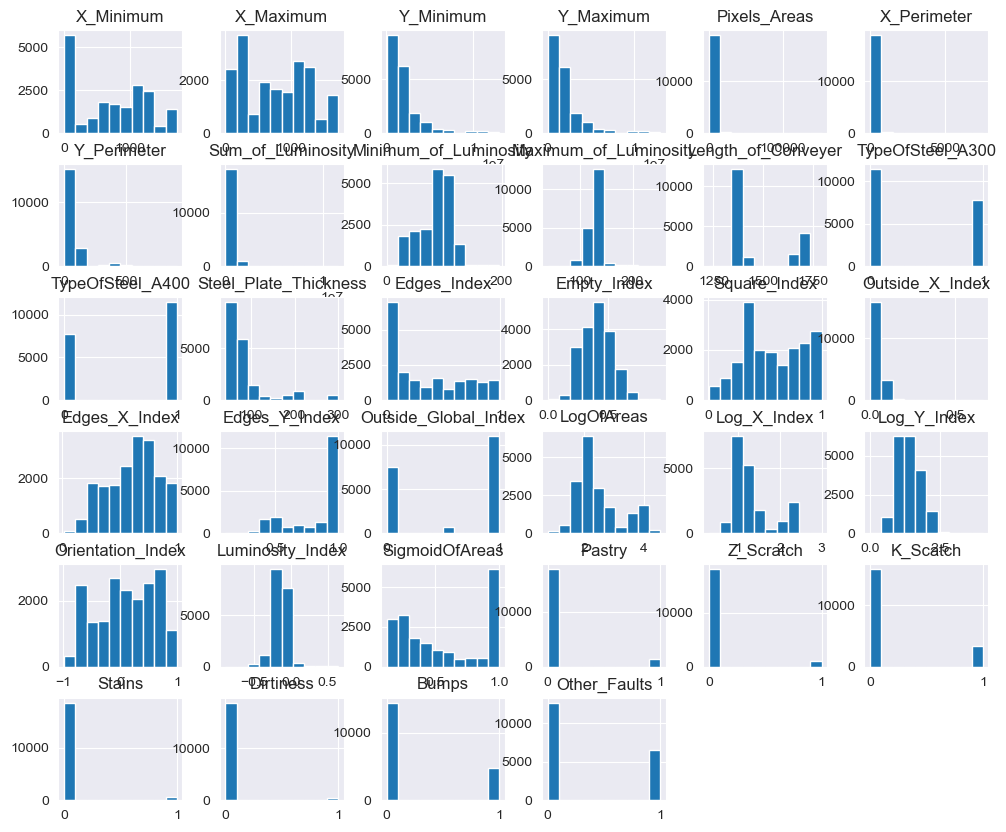

In [4]:
df.hist(figsize=(12, 10))

### Подключаем seaborn

array([[<Axes: title={'center': 'X_Minimum'}>,
        <Axes: title={'center': 'X_Maximum'}>,
        <Axes: title={'center': 'Y_Minimum'}>,
        <Axes: title={'center': 'Y_Maximum'}>,
        <Axes: title={'center': 'Pixels_Areas'}>,
        <Axes: title={'center': 'X_Perimeter'}>],
       [<Axes: title={'center': 'Y_Perimeter'}>,
        <Axes: title={'center': 'Sum_of_Luminosity'}>,
        <Axes: title={'center': 'Minimum_of_Luminosity'}>,
        <Axes: title={'center': 'Maximum_of_Luminosity'}>,
        <Axes: title={'center': 'Length_of_Conveyer'}>,
        <Axes: title={'center': 'TypeOfSteel_A300'}>],
       [<Axes: title={'center': 'TypeOfSteel_A400'}>,
        <Axes: title={'center': 'Steel_Plate_Thickness'}>,
        <Axes: title={'center': 'Edges_Index'}>,
        <Axes: title={'center': 'Empty_Index'}>,
        <Axes: title={'center': 'Square_Index'}>,
        <Axes: title={'center': 'Outside_X_Index'}>],
       [<Axes: title={'center': 'Edges_X_Index'}>,
        <Axes

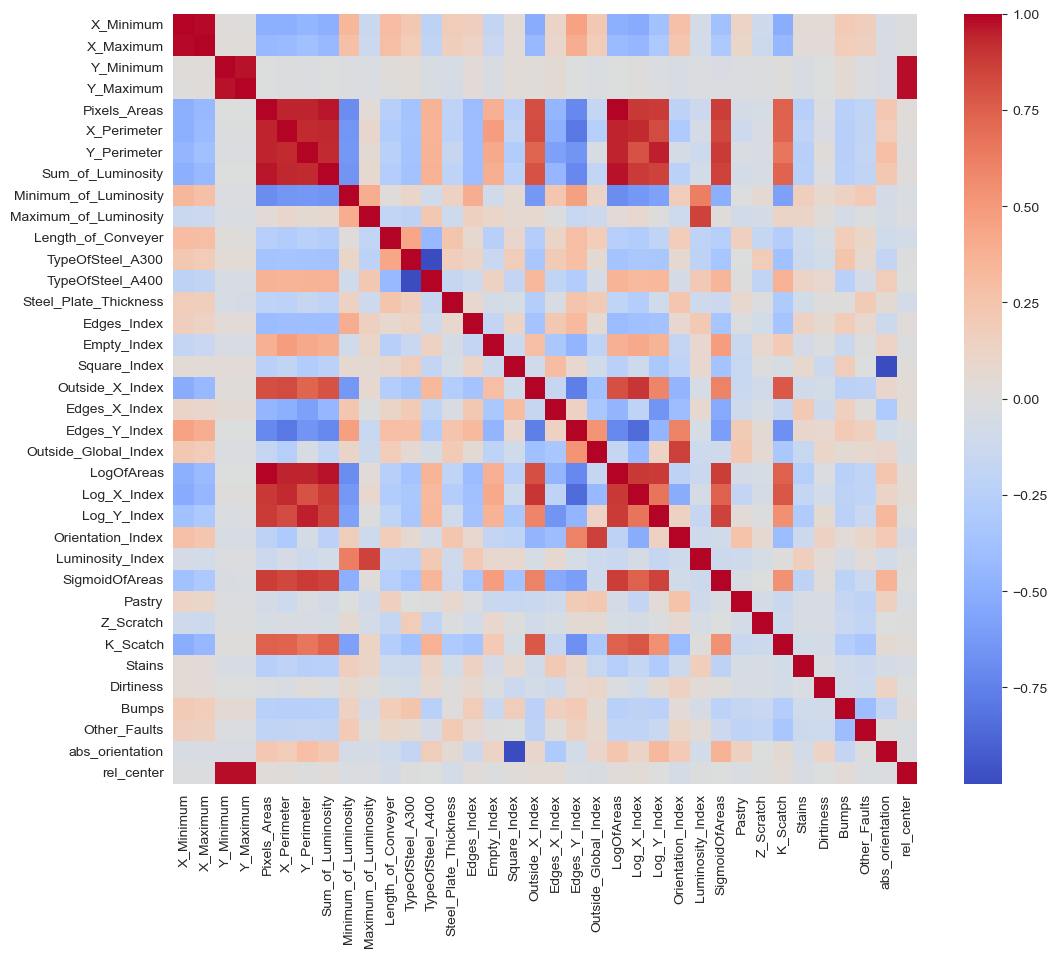

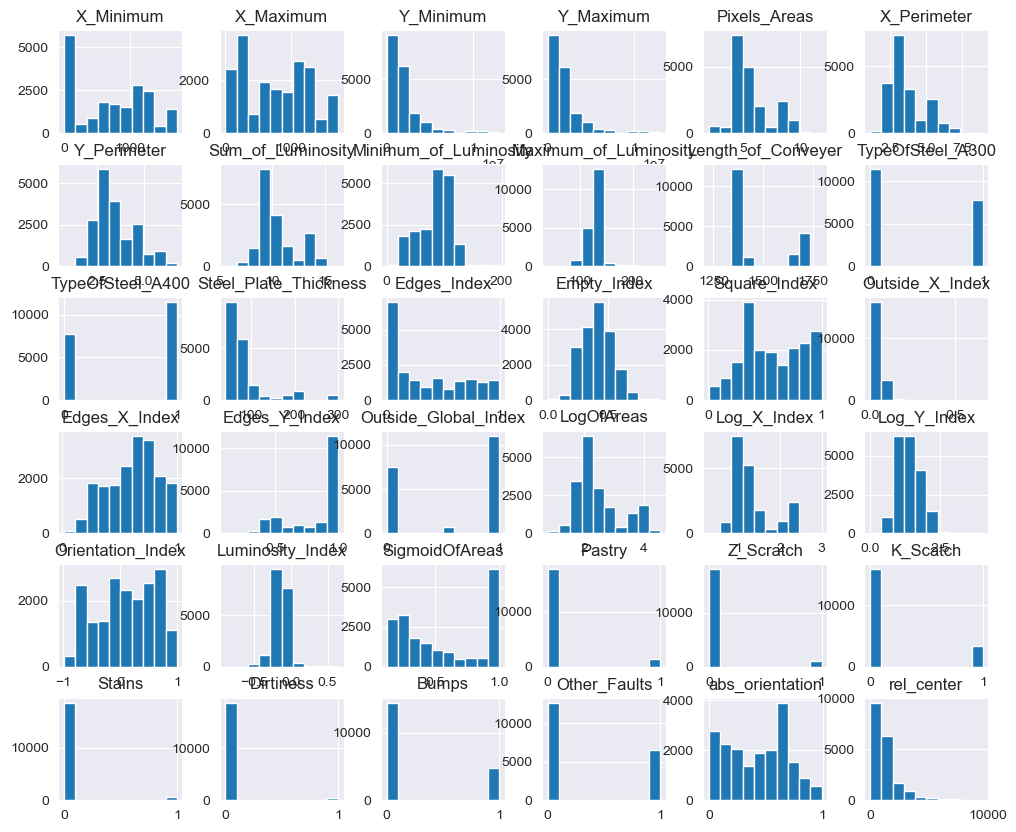

In [5]:
import seaborn as sns

df["abs_orientation"] = np.abs(df["Orientation_Index"])
df["rel_center"] = (
                           (df["Y_Minimum"] + df["Y_Maximum"]) / 2
                   ) / df["Length_of_Conveyer"]
skew_cols = [
    "Pixels_Areas",
    "Sum_of_Luminosity",
    "X_Perimeter",
    "Y_Perimeter"
]
for col in skew_cols:
    df[col] = np.log1p(df[col])
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
df.hist(figsize=(12, 10))

### Выделяем цели

In [6]:
y = df[targets]
X = df.drop(columns=targets)
print(f"📊 Размеры данных:")
print(f"X (признаки): {X.shape}")
print(f"y (целевая переменная): {y.shape}")

📊 Размеры данных:
X (признаки): (19219, 29)
y (целевая переменная): (19219, 7)


### Масштабируем данные

In [7]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f" Разделение данных:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тестовой выборке: {y_test.value_counts().to_dict()}")
scales = StandardScaler()
X_train_scaled = scales.fit_transform(X_train)
X_test_scaled = scales.transform(X_test)
print(f"\n Список признаков ({len(X.columns)}):")
for i, feature in enumerate(X.columns):
    print(f"{i + 1}. {feature}")

 Разделение данных:
Обучающая выборка: (15375, 29)
Тестовая выборка: (3844, 29)
Распределение классов в обучающей выборке: {(0, 0, 0, 0, 0, 0, 1): 5191, (0, 0, 0, 0, 0, 1, 0): 3837, (0, 0, 1, 0, 0, 0, 0): 2731, (1, 0, 0, 0, 0, 0, 0): 1164, (0, 1, 0, 0, 0, 0, 0): 930, (0, 0, 0, 0, 0, 0, 0): 635, (0, 0, 0, 1, 0, 0, 0): 468, (0, 0, 0, 0, 1, 0, 0): 400, (0, 0, 1, 0, 0, 0, 1): 18, (1, 0, 1, 0, 0, 0, 0): 1}
Распределение классов в тестовой выборке: {(0, 0, 0, 0, 0, 0, 1): 1349, (0, 0, 0, 0, 0, 1, 0): 924, (0, 0, 1, 0, 0, 0, 0): 680, (1, 0, 0, 0, 0, 0, 0): 301, (0, 1, 0, 0, 0, 0, 0): 220, (0, 0, 0, 0, 0, 0, 0): 183, (0, 0, 0, 1, 0, 0, 0): 100, (0, 0, 0, 0, 1, 0, 0): 85, (0, 0, 1, 0, 0, 1, 0): 2}

 Список признаков (29):
1. X_Minimum
2. X_Maximum
3. Y_Minimum
4. Y_Maximum
5. Pixels_Areas
6. X_Perimeter
7. Y_Perimeter
8. Sum_of_Luminosity
9. Minimum_of_Luminosity
10. Maximum_of_Luminosity
11. Length_of_Conveyer
12. TypeOfSteel_A300
13. TypeOfSteel_A400
14. Steel_Plate_Thickness
15. Edges_Index


### Проверяем баланс

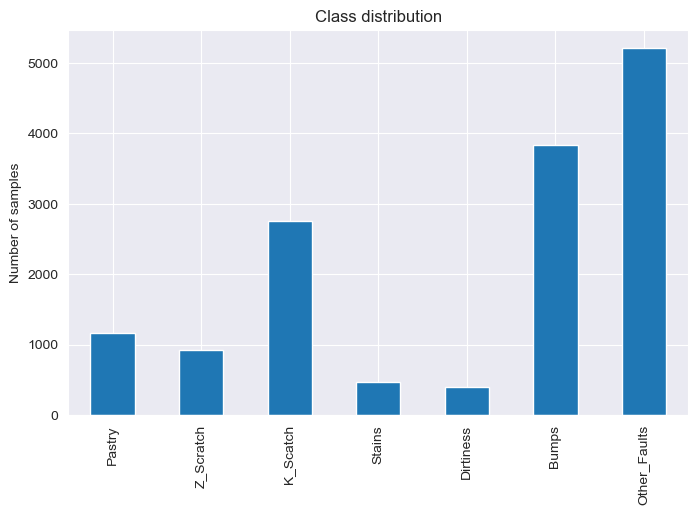

In [21]:
y_train.sum().plot(kind='bar', figsize=(8,5))
plt.title('Class distribution')
plt.ylabel('Number of samples')
plt.show()

### Собираем модели

In [8]:
models = {
    'Логистическая регрессия': {
        'model': OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000,verbose=True)),
        'Scaled': True
    },
    'Случайный лес': {
        'model': OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42,verbose=True)),
        'Scaled': False
    },
    'SVM (линейный)': {
        'model': OneVsRestClassifier(SVC(kernel='linear', random_state=42, probability=True,verbose=True)),
        'Scaled': True,
    },
    'k-NN': {
        'model': OneVsRestClassifier(KNeighborsClassifier()),
        'Scaled': True
    # },
    # 'SVM (RBF)': {
    #     'model': OneVsRestClassifier(SVC(kernel='rbf', random_state=42, probability=True)),
    #     'Scaled': True,
    # }
}}

### Готовим метрику

In [9]:

from sklearn.metrics import make_scorer

results = {}
trained_models = {}

for name, info in models.items():
    model = info['model']
    use_scaled = info['Scaled']

    if use_scaled:
        X_train_current = X_train_scaled
        X_test_current = X_test_scaled
    else:
        X_train_current = X_train
        X_test_current = X_test
    print('Начинаем обучение')
    model.fit(X_train_current, y_train)
    hamming_scorer = make_scorer(hamming_loss, greater_is_better=False)

    cv_scores = cross_val_score(model, X_train_current, y_train, cv=5, scoring=hamming_scorer)
    y_pred = model.predict(X_test_current)
    proba = model.predict_proba(X_test_current)
    roc_auc = roc_auc_score(y_test, proba, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    cv_ham_loss = -cv_scores.mean()
    cv_ham_acc = 1 - cv_ham_loss

    results[name] = {
        'model': name,
        'cv_hamming_acc': cv_ham_acc,
        'cv_hamming_loss': cv_ham_loss,
        'cv_scores_std': cv_scores.std(),
        'ham_acc': 1 - hamming_loss(y_test, y_pred),
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'roc_auc': roc_auc,
    }
    trained_models[name] = model

Начинаем обучение


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Начинаем обучение


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    3.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: 

Начинаем обучение
[LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM][LibSVM]Начинаем обучение


### Формируем таблицу

In [18]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('f1_macro', ascending=False)
results_df = results_df[['cv_hamming_acc','ham_acc','f1_micro','f1_macro','roc_auc']]
print(results_df)

                        cv_hamming_acc   ham_acc  f1_micro  f1_macro   roc_auc
k-NN                          0.878551  0.877992  0.493599  0.437666  0.781817
Случайный лес                 0.891057  0.891519    0.4766  0.419993  0.870122
Логистическая регрессия       0.888706  0.889475  0.446801  0.379858  0.863111
SVM (линейный)                0.886913  0.887952  0.370169  0.258782  0.834613


### Строим график

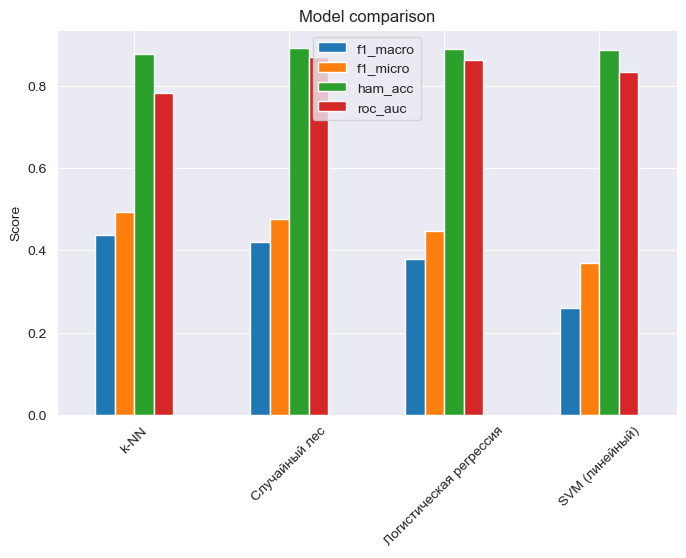

In [22]:
results_df[['f1_macro','f1_micro','ham_acc','roc_auc']].plot(kind='bar', figsize=(8,5))
plt.title('Model comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

### Настраиваем RF

In [24]:
def optimize_random_forest_with_optuna(trial,X_train,y_train):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 5, 300),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = OneVsRestClassifier(RandomForestClassifier(**params))
    f1_macro = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_macro')
    return f1_macro.mean()


def optimize_knn_with_optuna(trial, X_train, y_train):
    """Оптимизация гиперпараметров k-NN"""
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
    }

    if params['metric'] == 'minkowski':
        params['p'] = trial.suggest_int('p', 1, 3)

    model = KNeighborsClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_macro')
    return scores.mean()



### Задаем trials

In [25]:
N_TRIALS = 100  # Количество попыток для каждой модели
TIMEOUT = 300

### Собираем функции

In [28]:
optimization_functions = {
    'k-NN': optimize_knn_with_optuna,
    'Случайный лес': optimize_random_forest_with_optuna,
}
optimized_results = {}
optimization_studies = {}
optimization_times = {}
start_total_time = time.time()

for model_name,func in optimization_functions.items():
    print(f'Начинаем Оптимизацию {model_name}')
    use_scaled = models[model_name]['Scaled']
    X_train_current = X_train_scaled if use_scaled else X_train
    X_test_current = X_test_scaled if use_scaled else X_test
    start_time = time.time()
    study = optuna.create_study(direction='maximize',sampler=TPESampler(seed=42))
    study.optimize(
        lambda trial: func(trial, X_train_current, y_train),
        n_trials=N_TRIALS,
        timeout=TIMEOUT,
        show_progress_bar=True
    )
    end_time = time.time()
    optimization_time = end_time - start_time
    optimization_times[model_name] = optimization_time

    optimization_studies[model_name] = study
    best_params = study.best_params
    best_score = study.best_value
    print(f"    Завершено за {optimization_time:.1f} секунд")
    print(f"    Лучший F1_macro: {best_score:.4f}")
    print(f"   Проведено {len(study.trials)} попыток")
    if model_name == 'Случайный лес':
        optimized_model = OneVsRestClassifier(RandomForestClassifier(**best_params))
    elif model_name == 'k-NN':
        optimized_model = OneVsRestClassifier(KNeighborsClassifier(**best_params))
    optimized_model.fit(X_train_current, y_train)
    y_pred_opt = optimized_model.predict(X_test_current)
    y_pred_proba_opt = optimized_model.predict_proba(X_test_current)
    f1_macro_scores = cross_val_score(optimized_model, X_train_current, y_train, cv=5, scoring='f1_macro')
    roc_auc_current = roc_auc_score(y_test,y_pred_proba_opt,average='macro')
    optimized_results[model_name] = {
        'best_params': best_params,
        'best_f1_score': best_score,
        'roc_auc': roc_auc_current,
        'predictions': y_pred_opt,
        'probabilities': y_pred_proba_opt,
        'n_trials': len(study.trials),
        'optimization_time': optimization_time,
        'model': optimized_model
    }
    total_time = time.time() - start_total_time

[I 2026-03-13 23:08:11,973] A new study created in memory with name: no-name-9b17d6fa-f8f7-48f7-b650-b1b6113ebaba


Начинаем Оптимизацию k-NN


Best trial: 0. Best value: 0.441366:   1%|          | 1/100 [00:03<05:02,  3.06s/it, 3.05/300 seconds]

[I 2026-03-13 23:08:15,080] Trial 0 finished with value: 0.44136615698960585 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'ball_tree'}. Best is trial 0 with value: 0.44136615698960585.


Best trial: 1. Best value: 0.443454:   2%|▏         | 2/100 [00:05<04:44,  2.91s/it, 5.86/300 seconds]

...

[I 2026-03-13 23:16:47,254] Trial 6 finished with value: 0.385893406631451 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.41575365179140616.


Best trial: 0. Best value: 0.415754:   8%|▊         | 8/100 [03:58<1:05:34, 42.76s/it, 238.91/300 seconds]

[I 2026-03-13 23:17:58,394] Trial 7 finished with value: 0.4065376304344117 and parameters: {'n_estimators': 233, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.41575365179140616.


Best trial: 0. Best value: 0.415754:   9%|▉         | 9/100 [05:14<53:00, 34.95s/it, 314.58/300 seconds]  


[I 2026-03-13 23:19:14,059] Trial 8 finished with value: 0.23938820794450022 and parameters: {'n_estimators': 260, 'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.41575365179140616.
    Завершено за 314.6 секунд
    Лучший F1_macro: 0.4158
   Проведено 9 попыток


### Сопоставляем улучшения

In [36]:
for model_name in results.keys():
    # Результаты до оптимизации
    if model_name in optimized_results.keys():
        before_f1_macro = results[model_name]['f1_macro']
        before_roc_auc = results[model_name]['roc_auc']
        after_roc_auc = optimized_results[model_name]['roc_auc']
        after_f1_macro = optimized_results[model_name]['best_f1_score']
        print(f'Улучшение Roc_Auc для модели {model_name}: {after_roc_auc - before_roc_auc:.5f}')
        print(f'Улучшение f1_macro для модели {model_name}: {after_f1_macro - before_f1_macro:.5f}')

Улучшение Roc_Auc для модели Случайный лес: 0.00748
Улучшение f1_macro для модели Случайный лес: -0.00424
Улучшение Roc_Auc для модели k-NN: 0.00467
Улучшение f1_macro для модели k-NN: 0.01834


### Обучаем модель

In [39]:
final_model = (OneVsRestClassifier
               (KNeighborsClassifier(**(optimized_results['k-NN']['best_params']))))

# data_train = data_train.drop(columns=['id'])
# data_real = data_real.drop(columns=['id'])
data_train["abs_orientation"] = np.abs(data_train["Orientation_Index"])
data_real["abs_orientation"] = np.abs(data_real["Orientation_Index"])
data_train["rel_center"] = (
                           (data_train["Y_Minimum"] + data_train["Y_Maximum"]) / 2
                   ) / data_train["Length_of_Conveyer"]
data_real["rel_center"] = (
                           (data_real["Y_Minimum"] + data_real["Y_Maximum"]) / 2
                   ) / data_real["Length_of_Conveyer"]
skew_cols = [
    "Pixels_Areas",
    "Sum_of_Luminosity",
    "X_Perimeter",
    "Y_Perimeter"
]
for col in skew_cols:
    data_train[col] = np.log1p(data_train[col])
    data_real[col] = np.log1p(data_real[col])
X=data_train.drop(columns=targets)
y=data_train[targets]
scaler = StandardScaler()
data_train_scaled=scaler.fit_transform(X)
data_real_scaled=scaler.transform(data_real)
final_model.fit(data_train_scaled, y)

,estimator,KNeighborsCla...c='manhattan')
,n_jobs,None
,verbose,0
,n_neighbors,5
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


### Считаем вероятности

In [43]:
y_proba = final_model.predict_proba(data_real_scaled)
submission = pd.DataFrame(y_proba, columns=y.columns)
submission.insert(0, 'id', data_real['id'])
submission.to_csv('submission.csv', index=False)